In [14]:
# === IMPORT LIBRARY ===
import pandas as pd
import re
import string
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# === DOWNLOAD NLTK RESOURCES ===
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

# === STOPWORDS ===
stop_words = set(stopwords.words("english"))


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [15]:
# === LOAD DATASET ===
data = pd.read_csv('reviews.csv')

# === DROP KOLOM TIDAK DIPAKAI ===
columns_to_drop = [
    's.no', 'helpfulVoteCount', 'images/0', 'images/1', 'images/2', 'images/3', 'images/4', 'images/5',
    'images/6', 'images/7', 'reviewID', 'reviewMetadata', 'productVariant',
    'reviewPosition', 'reviewTitle', 'reviewURL', 'verifiedPurchase',
    'videos/0', 'cleaned_review_text', 'rating', 'productASIN'
]
data.drop(columns=columns_to_drop, inplace=True, errors='ignore')

# === CEK DATA KOSONG & ISI NILAI DEFAULT ===
print(f"NaN reviewText : {data['reviewText'].isnull().sum()}")
print(f"NaN sentiment_score : {data['sentiment_score'].isnull().sum()}")

data['reviewText'].fillna('data Not Found', inplace=True)


NaN reviewText : 38
NaN sentiment_score : 0


/tmp/ipython-input-15-2109948479.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['reviewText'].fillna('data Not Found', inplace=True)


In [16]:
# === LABEL SENTIMEN ===
def label_sentiment(score):
    if score > 0:
        return 'positive'
    elif score < 0:
        return 'negative'
    else:
        return 'neutral'

data['label'] = data['sentiment_score'].apply(label_sentiment)


In [17]:
# === PREPROCESSING TEXT ===
def preprocess_text(text):
    if pd.isna(text):
        return ""
    text = text.lower()  # lowercase
    text = re.sub(r'[^a-z\s]', '', text)  # hapus angka dan simbol
    tokens = word_tokenize(text)  # tokenisasi
    filtered = [word for word in tokens if word not in stop_words]  # hapus stopwords
    return " ".join(filtered)

# === APPLY PREPROCESSING ===
data["cleaned_text"] = data["reviewText"].apply(preprocess_text)


In [18]:
# === TF-IDF ===
tfidf = TfidfVectorizer(max_features=1000)
X = tfidf.fit_transform(data["cleaned_text"])

# === ENCODE LABEL ===
le = LabelEncoder()
y = le.fit_transform(data["label"])

# Tampilkan mapping label
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Mapping label:", label_mapping)


Mapping label: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}


In [19]:
# === SPLIT TRAIN & TEST ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Training: {X_train.shape[0]} data")
print(f"Testing : {X_test.shape[0]} data")


Training: 5061 data
Testing : 1266 data



=== Logistic Regression ===
Akurasi: 0.9400
Classification Report:
              precision    recall  f1-score   support

    negative       0.86      0.21      0.34        57
     neutral       0.96      0.44      0.60        50
    positive       0.94      1.00      0.97      1159

    accuracy                           0.94      1266
   macro avg       0.92      0.55      0.64      1266
weighted avg       0.94      0.94      0.93      1266



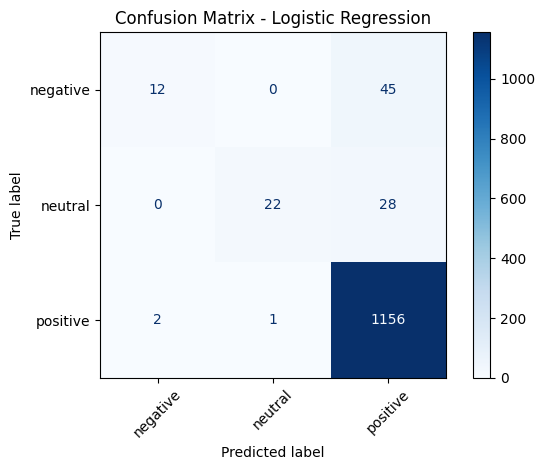


=== Support Vector Machine ===
Akurasi: 0.9431
Classification Report:
              precision    recall  f1-score   support

    negative       1.00      0.09      0.16        57
     neutral       0.94      0.64      0.76        50
    positive       0.94      1.00      0.97      1159

    accuracy                           0.94      1266
   macro avg       0.96      0.58      0.63      1266
weighted avg       0.95      0.94      0.93      1266



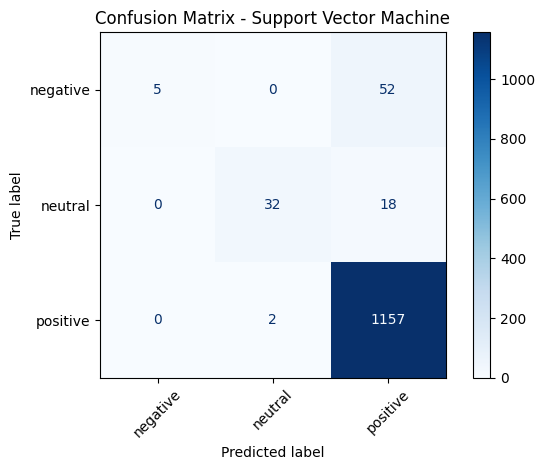


=== Random Forest ===
Akurasi: 0.9439
Classification Report:
              precision    recall  f1-score   support

    negative       0.75      0.16      0.26        57
     neutral       0.71      0.84      0.77        50
    positive       0.96      0.99      0.97      1159

    accuracy                           0.94      1266
   macro avg       0.81      0.66      0.67      1266
weighted avg       0.94      0.94      0.93      1266



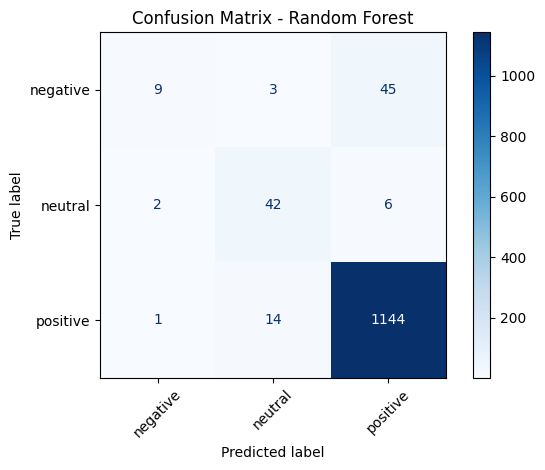

In [20]:
# === MODEL TRAINING DAN EVALUASI ===
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Support Vector Machine": SVC(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

for name, model in models.items():
    print(f"\n=== {name} ===")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print(f"Akurasi: {acc:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    # === CONFUSION MATRIX VISUAL ===
    ConfusionMatrixDisplay.from_estimator(
        model, X_test, y_test, display_labels=le.classes_,
        cmap='Blues', xticks_rotation=45
    )
    plt.title(f"Confusion Matrix - {name}")
    plt.tight_layout()
    plt.show()
